Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)


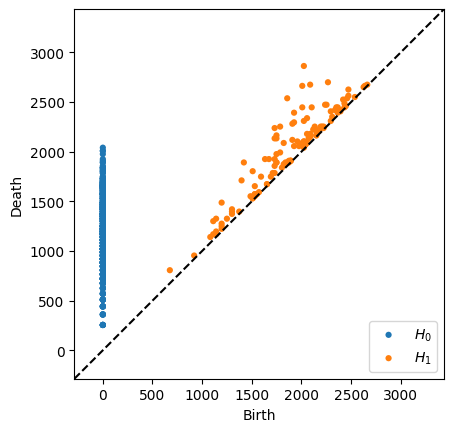

In [1]:
from PIL import Image
import numpy as np
from ripser import Rips
import matplotlib.pyplot as plt

Path = r'./DRIVE/test/1st_manual/01_manual1.gif'

# Read the image
image = Image.open(Path)

# Convert the resized image to a NumPy array
image_array = np.array(image)

# Create a Rips object
rips = Rips(coeff=2)

# Compute the persistence diagrams
diagrams = rips.fit_transform(image_array)

# Convert the list of diagrams to a NumPy array
diagrams_array = np.array(diagrams, dtype=object)

# Filter points with a lifetime below min_lifetime and remove infinite values
min_lifetime = 0
valid_diagrams = []

for diagram in diagrams_array:
    # Filter out points with a lifetime below min_lifetime
    valid_diagram = diagram[diagram[:, 1] - diagram[:, 0] >= min_lifetime]
    
    # Remove points with infinite values
    valid_diagram = valid_diagram[~np.isinf(valid_diagram[:, 1])]
    
    valid_diagrams.append(valid_diagram)

# Plot the valid persistence diagrams
rips.plot(valid_diagrams)

# Display the plot
plt.show()


In [2]:
H1_diagram = valid_diagrams[1]

In [3]:
from persim import PersistenceImager
pimgr_1 = PersistenceImager(pixel_size=100)
pimgr_1.fit(H1_diagram)

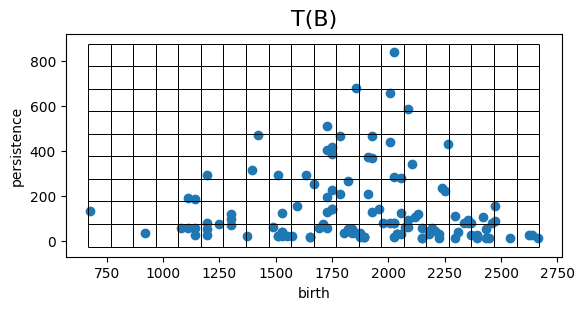

In [4]:
pimgr_1.plot_diagram(H1_diagram, skew=True)
plt.title('T(B)', fontsize=16)  
plt.show()  

<Axes: xlabel='birth', ylabel='persistence'>

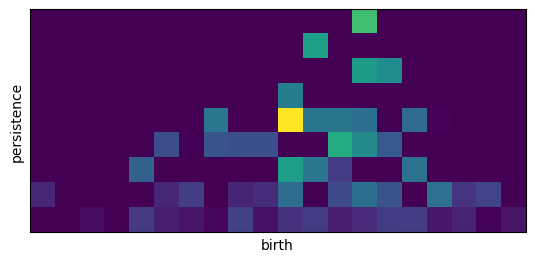

In [6]:
persistence_image = pimgr_1.transform(H1_diagram)
pimgr_1.plot_image(persistence_image)


(500, 500)


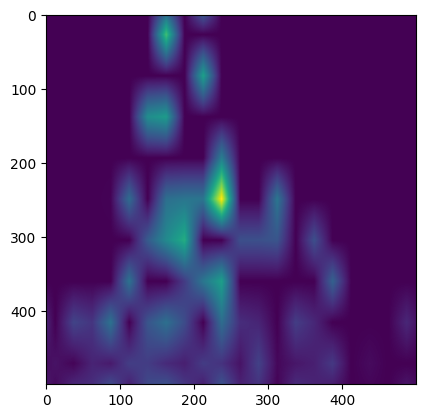

In [ ]:
import numpy as np
from persim.images_weights import linear_ramp
from skimage.transform import resize
import matplotlib.pyplot as plt

# Set weight parameters
pimgr_1.weight = linear_ramp
pimgr_1.weight_params = {'low': 0.0, 'high': 1.0, 'start': 0.0, 'end': 1000.0}

# Compute the persistence image
persistence_image = pimgr_1.transform(H1_diagram)

# Resize the image
resized_image = resize(persistence_image, (500, 500), mode='reflect')

# Flip upside down and rotate 90° counterclockwise (left rotation)
resized_image_rotated = np.rot90(np.flipud(resized_image), k=1)

# Display the image
print(resized_image_rotated.shape)
plt.imshow(resized_image_rotated, cmap='viridis')
plt.show()







In [11]:
import numpy as np
from scipy.io import savemat
savemat('./test.mat', {'image': resized_image_rotated})

print("MAT SAVED")

MAT SAVED


250000
Shape of the loaded data: (500, 500)


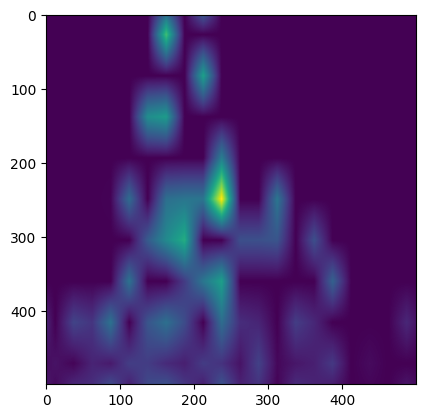

In [12]:
from scipy.io import loadmat
import matplotlib.pyplot as plt

# Load the .mat file
data = loadmat('./test.mat')

# Access the saved data
resized_image_rotated_left_loaded = data['image']
print(resized_image_rotated_left_loaded.size)

# Print the shape of the loaded data
print("Shape of the loaded data:", resized_image_rotated_left_loaded.shape)
plt.imshow(resized_image_rotated_left_loaded, cmap='viridis')

In [319]:
matrix_max = np.max(resized_image_rotated_left_loaded)
matrix_min = np.min(resized_image_rotated_left_loaded)

print(f"矩阵的最大值是: {matrix_max}")
print(f"矩阵的最小值是: {matrix_min}")

矩阵的最大值是: 1.290373446269532
矩阵的最小值是: -9.678514234454113e-18


矩阵的最大值是: 1.0
矩阵的最小值是: 0.0


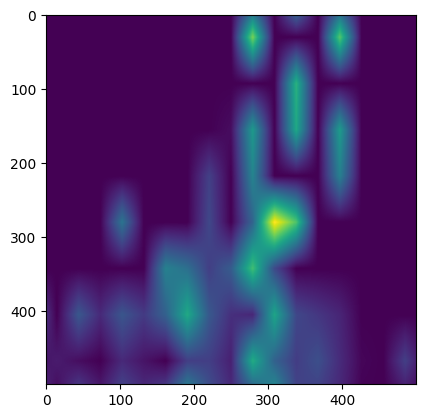

In [321]:
# 把所有小于 0 的值变成 0
resized_image_rotated_left_loaded[resized_image_rotated_left_loaded < 0] = 0
resized_image_rotated_left_loaded[resized_image_rotated_left_loaded > 1] = 1

matrix_max = np.max(resized_image_rotated_left_loaded)
matrix_min = np.min(resized_image_rotated_left_loaded)

print(f"矩阵的最大值是: {matrix_max}")
print(f"矩阵的最小值是: {matrix_min}")


plt.imshow(resized_image_rotated_left, cmap='viridis')
